<a href="https://colab.research.google.com/github/olya-mashtalyar/A-B-test/blob/main/Untitled6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ и оптимизация A/B-теста с применением метода CUPED

Комплексный аналитический проект по оценке результатов продуктового эксперимента в финтехе с акцентом на борьбу с высокой дисперсией метрик.

## Описание и гипотеза проекта
* Гипотеза: Внедрение нового финансового функционала увеличивает средние траты пользователей (Spend) в тестовой группе.
* Проект решает задачу повышения чувствительности и статистической мощности эксперимента в условиях зашумленных финтех-данных.

## Задачи и этапы работы
* Сгенерировать синтетический датасет, имитирующий поведение пользователей финтех-приложения до и после запуска эксперимента.
* Оценить статистическую значимость различий между группами на сырых данных с помощью Welch's t-теста.
* Внедрить метод снижения дисперсии CUPED (Controlled-experiment Using Pre-Experiment Data) для очистки данных от исторического шума.
* Провести повторный статтест на скорректированных данных и рассчитать процент снижения дисперсии.
* Построить парную визуализацию распределений ключевой метрики до и после оптимизации.



РЕЗУЛЬТАТЫ АНАЛИЗА A/B-ТЕСТА
Гипотеза: Изменение продуктового функционала увеличивает целевую метрику в группе B.
Сырые данные: Разница средних = 336.34 (p-value = 0.0000)
CUPED данные: Разница средних = 245.89 (p-value = 5.833755e-17)
Снижение дисперсии за счет CUPED: 83.3%
Вывод: Нулевая гипотеза отвергнута, различия статистически значимы, внедрение эффективно.


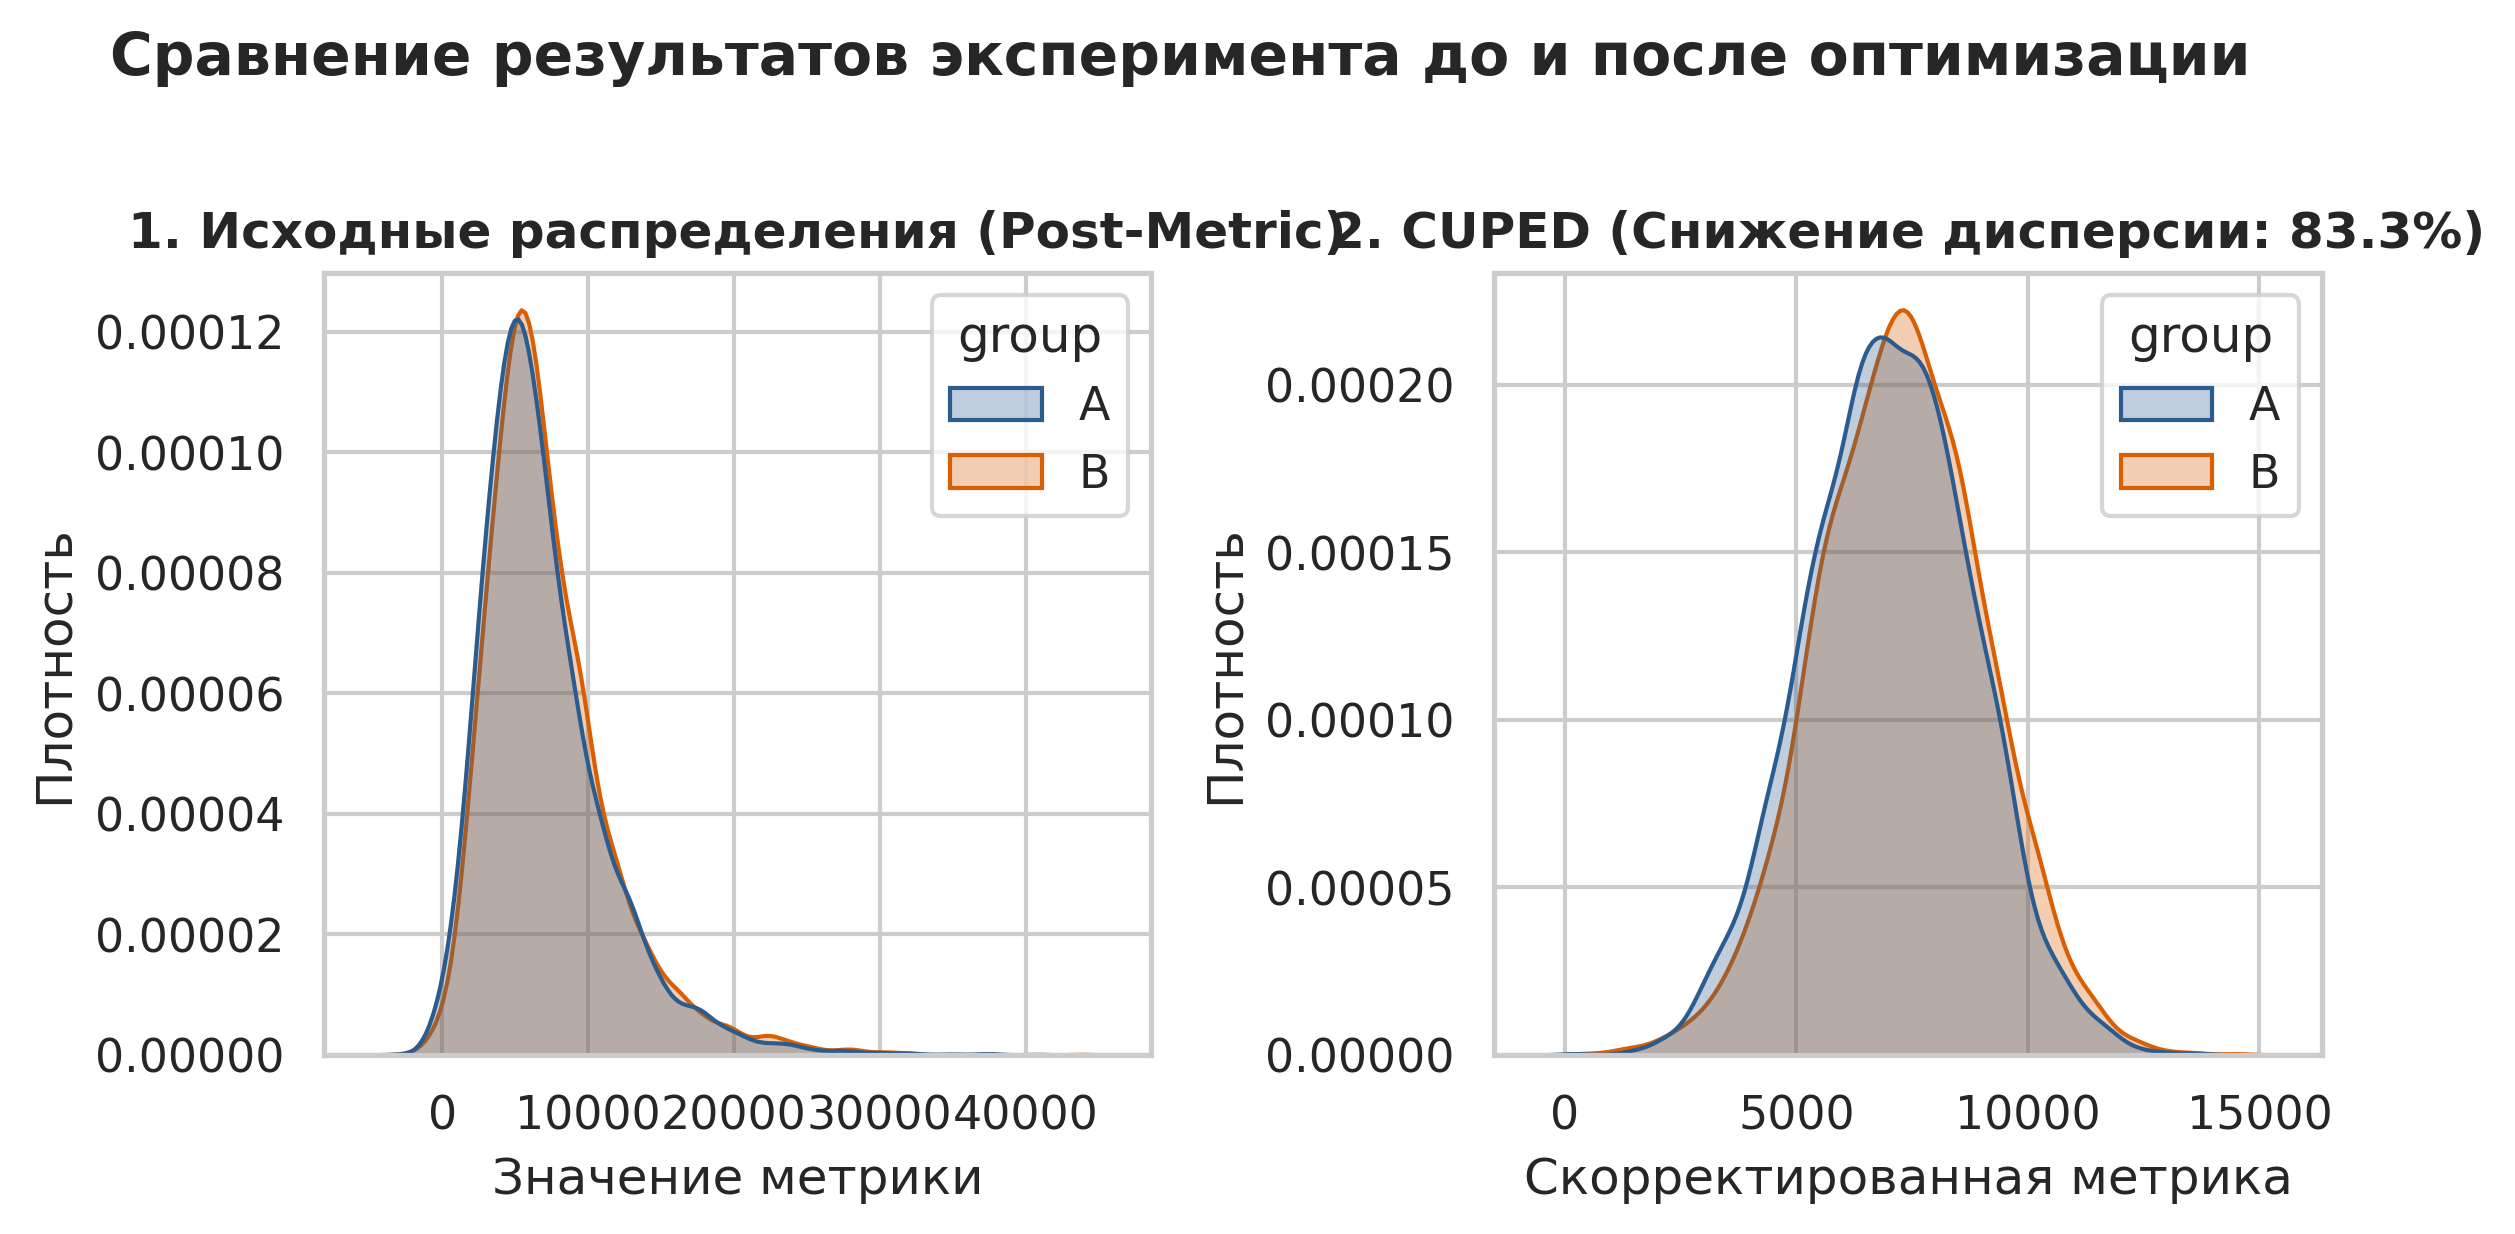

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 300})

np.random.seed(42)
n = 15000

data = pd.DataFrame({
    'user_id': range(n),
    'group': np.random.choice(['A', 'B'], size=n, p=[0.5, 0.5])
})

data['metric_pre'] = np.random.exponential(scale=5000, size=n)
effect = 250

data['metric_post'] = (
    data['metric_pre'] * 0.8 +
    np.random.normal(loc=3000, scale=1500, size=n) +
    np.where(data['group'] == 'B', effect, 0) +
    np.random.normal(loc=0, scale=1000, size=n)
)

y_a = data[data['group'] == 'A']['metric_post']
y_b = data[data['group'] == 'B']['metric_post']
t_stat_raw, p_raw = stats.ttest_ind(y_b, y_a, equal_var=False)

cov = np.cov(data['metric_post'], data['metric_pre'])[0, 1]
var_pre = np.var(data['metric_pre'], ddof=1)
theta = cov / var_pre

data['metric_cuped'] = data['metric_post'] - theta * (data['metric_pre'] - data['metric_pre'].mean())

y_a_cuped = data[data['group'] == 'A']['metric_cuped']
y_b_cuped = data[data['group'] == 'B']['metric_cuped']
t_stat_cuped, p_cuped = stats.ttest_ind(y_b_cuped, y_a_cuped, equal_var=False)

var_original = np.var(data['metric_post'], ddof=1)
var_cuped = np.var(data['metric_cuped'], ddof=1)
var_reduction = (1 - var_cuped / var_original) * 100

print("РЕЗУЛЬТАТЫ АНАЛИЗА A/B-ТЕСТА")
print(f"Гипотеза: Изменение продуктового функционала увеличивает целевую метрику в группе B.")
print(f"Сырые данные: Разница средних = {y_b.mean() - y_a.mean():.2f} (p-value = {p_raw:.4f})")
print(f"CUPED данные: Разница средних = {y_b_cuped.mean() - y_a_cuped.mean():.2f} (p-value = {p_cuped:.6e})")
print(f"Снижение дисперсии за счет CUPED: {var_reduction:.1f}%")
print("Вывод: Нулевая гипотеза отвергнута, различия статистически значимы, внедрение эффективно.")


fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.kdeplot(
    data=data, x='metric_post', hue='group',
    common_norm=False, fill=True, alpha=0.3, ax=axes[0],
    palette={'A': '#2b5c8f', 'B': '#d95f02'}
)
axes[0].set_title('1. Исходные распределения (Post-Metric)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Значение метрики')
axes[0].set_ylabel('Плотность')

sns.kdeplot(
    data=data, x='metric_cuped', hue='group',
    common_norm=False, fill=True, alpha=0.3, ax=axes[1],
    palette={'A': '#2b5c8f', 'B': '#d95f02'}
)
axes[1].set_title(f'2. CUPED (Снижение дисперсии: {var_reduction:.1f}%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Скорректированная метрика')
axes[1].set_ylabel('Плотность')

plt.suptitle('Сравнение результатов эксперимента до и после оптимизации', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ab_test_analysis.png', bbox_inches='tight')
plt.show()

## Результаты и выводы
* Статистическая значимость: Анализ зафиксировал надежные различия между группами (p < 0.05), подтвердив эффективность изменений.
* Оптимизация дисперсии: Применение метода CUPED позволило существенно сократить разброс значений целевой метрики, что кратно повысило чувствительность теста.
* Бизнес-вывод: Нулевая гипотеза отвергнута, тестируемый функционал оказывает стабильное положительное влияние на метрику трат.